In [1]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

def get_dataframe_from_records(records, add_custom_columns=None):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    if add_custom_columns:
        df = add_custom_columns(df)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])
    # chech that for each group there are 5 entries

    agg_df_check = df.groupby("group").count()
    if (agg_df_check < 5).any().any():
        print("Warning: Some groups have fewer than 5 entries.")

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"
        
        #set min value to row[std_col] to 0.001

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def only_best(run):
    return run.group is not None and run.group.startswith("best_")

def get_records(project, metrics=[], history=[], config=[], get_memory=False, pattern=only_best, verbose=False, regex=None):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    if not regex:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished"}) #, "group":{"$regex": "^best_"}})
    else:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished", "group": {"$regex": regex}})

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not pattern(run):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        if verbose:
            print(f"Processing run {run.id} in group '{group}'")
            # print metrics of the run
            print("Metrics:", [key for key in run.summary.keys() if key.startswith("test_")])

        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        for metric, mode in history:
            if metric not in run.history(keys=[metric]).columns:
                print(f"Warning: Metric '{metric}' not found in history of run {run.id}.")
                continue
            if mode == 'max':
                record[metric] = run.history(keys=[metric])[metric].dropna().max()
            elif mode == 'min':
                record[metric] = run.history(keys=[metric])[metric].dropna().min()
            else:
                record[metric] = run.history(keys=[metric])[metric].dropna().values[-1]

        for c in config:
            if c not in run.config:
                print(f"Warning: Config '{c}' not found in run {run.id}.")
                continue
            record[c] = run.config[c]

        if get_memory:
            # get the tag
            # print("Getting memory info for run:", run.id)
            tag = run.tags[0]
            assert tag.startswith('CUDA_VISIBLE_DEVICES_')
            cuda_device = tag.split('_')[-1]
            memory_metric_id = f'system.gpu.{cuda_device}.memoryAllocatedBytes'
            record['memory'] = run.system_metrics[memory_metric_id]
            hist = run.history(stream='system')
            # print("System history columns:", hist.columns)
            record['memory2'] = hist[memory_metric_id].max()

        records.append(record)
    return records

colors_idxs = {
    "best_stmem_ft": "#636EFAC0",
    "best_stmem_lp": "#636EFAC0",
    "best_jepa_ft": "#EF553BC0",
    "best_jepa_lp": "#EF553BC0",
    "best_ecgfm_ft": "#00CC96C0",
    "best_ecgfm_lp": "#00CC96C0",
    "best_trans_ft": "#AB63FAC0",
    "best_trans_lp": "#AB63FAC0",
    "best_xlstm_ft": "#FFA15AC0",
    "best_xlstm_lp": "#FFA15AC0",
    "best_xlstm_sup": "#19D3F3C0",
    "best_ecgcpc_lp": "#FFB6C1C0",
    "best_ecgcpc_ft": "#FFB6C1C0"
}

# base plots

In [2]:
records_sleep_apnea = get_records("train-sleep-apnea_bis", metrics=["test_acc", "test_f1", "test_auc", '_runtime'], config=['batch_size'], get_memory=True, regex="^best_")
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/q036rl/.netrc.
100%|██████████| 235/235 [04:03<00:00,  1.03s/it]


In [3]:
# plot with runtimes
dataframe = pd.DataFrame(records_sleep_apnea).set_index("group")
# print(dataframe[dataframe.index == 'best_trans_ft_9m'])
dataframe['memory_adjusted'] = dataframe['memory2'] / dataframe['batch_size']
dataframe['runtime_adjusted'] = dataframe['_runtime'] / dataframe['batch_size']
dataframe = dataframe[['test_auc', '_runtime', 'memory_adjusted', 'runtime_adjusted']].groupby(level=0).agg(['mean', 'std'])
dataframe['_runtime'] = dataframe['_runtime'] / 3600  # convert to hours
dataframe['runtime_adjusted'] = dataframe['runtime_adjusted'] / 3600  # convert to hours
dataframe['memory_adjusted'] = dataframe['memory_adjusted'] / (1024 * 1024 * 1024)  # convert to GB
dataframe

test_auc             _runtime            \
                              mean       std       mean       std   
group                                                               
best_code15_xlstm_lp      0.796271  0.033554   1.004830  0.002574   
best_code_15_xlstm_ft_3m  0.874788  0.007401   2.155640  0.005184   
best_dinoecg_xlstm_ft_3m  0.848669  0.036937   1.529975  0.011725   
best_dinoecg_xlstm_lp     0.861430  0.033526   0.570060  0.005603   
best_ecgcpc_ft_10s        0.702460  0.030427   1.560770  0.006112   
best_ecgcpc_ft_1m         0.793203  0.026644   1.718857  0.009486   
best_ecgcpc_ft_20s        0.737369  0.013653   1.550192  0.005445   
best_ecgcpc_ft_30s        0.698922  0.034332   1.562853  0.007479   
best_ecgcpc_ft_3m         0.928679  0.031295   6.505342  0.016462   
best_ecgcpc_ft_5m         0.924533  0.034394  10.950010  0.011649   
best_ecgcpc_ft_9m         0.935022  0.024055  22.696900  0.094842   
best_ecgcpc_lp            0.734442  0.065999   4.271535  0.003991   
best_ecgfm_ft_10s         0.691522  0.042679   0.749307  0.006829   
best_ecgfm_ft_1m          0.755818  0.028330   0.862217  0.005548   
best_ecgfm_ft_20s         0.732915  0.047445   0.750460  0.007801   
best_ecgfm_ft_30s         0.722750  0.040323   0.863424  0.008362   
best_ecgfm_ft_3m          0.741468  0.032091   2.442820  0.013378   
best_ecgfm_ft_5m          0.770809  0.056052   3.956516  0.008551   
best_ecgfm_ft_9m          0.778393  0.072225   6.986606  0.055395   
best_ecgfm_lp             0.776873  0.071249   1.908449  0.062734   
best_jepa_ft_10s          0.675331  0.012957   3.532854  0.024096   
best_jepa_ft_1m           0.690438  0.027731  13.199495  0.099019   
best_jepa_ft_20s          0.670907  0.016559   5.461037  0.020665   
best_jepa_ft_30s          0.652686  0.025504   7.564324  0.031646   
best_jepa_lp              0.666892  0.051432   5.554960  0.048852   
best_stmem_ft_10s         0.700258  0.030121   2.633463  0.016485   
best_stmem_ft_1m          0.684874  0.032594   8.005235  0.034683   
best_stmem_ft_20s         0.687620  0.035707   3.227487  0.746068   
best_stmem_ft_30s         0.682557  0.019784   4.843649  0.015482   
best_stmem_lp             0.598744  0.031628   1.104840  0.004465   
best_trans_ft_10s         0.658399  0.031726   0.186790  0.008206   
best_trans_ft_1m          0.629798  0.032487   0.230259  0.007112   
best_trans_ft_20s         0.619472  0.024882   0.193368  0.008290   
best_trans_ft_30s         0.598029  0.062210   0.198968  0.011423   
best_trans_ft_3m          0.614597  0.036484   1.032932  0.002321   
best_trans_ft_5m          0.636770  0.041220   2.363284  0.011192   
best_trans_ft_9m          0.680796  0.044048   6.401156  0.008044   
best_trans_lp             0.644381  0.042393   0.114470  0.002982   
best_xlstm_ft_10s         0.712283  0.048554   0.276146  0.006157   
best_xlstm_ft_1m          0.914163  0.019947   0.296956  0.002107   
best_xlstm_ft_20s         0.745335  0.027762   0.281945  0.001063   
best_xlstm_ft_30s         0.777324  0.029646   0.289069  0.001879   
best_xlstm_ft_3m          0.915131  0.015152   1.068406  0.004634   
best_xlstm_ft_5m          0.927839  0.008091   2.154556  0.010523   
best_xlstm_ft_9m          0.898796  0.022994   5.267718  0.019446   
best_xlstm_lp             0.879130  0.021273   1.016923  0.004160   
best_xlstm_sup            0.834288  0.019905   2.644200  0.008153   

                         memory_adjusted           runtime_adjusted            
                                    mean       std             mean       std  
group                                                                          
best_code15_xlstm_lp            0.299505  0.000014         0.007850  0.000020  
best_code_15_xlstm_ft_3m        0.923812  0.011801         0.067364  0.000162  
best_dinoecg_xlstm_ft_3m        0.933212  0.000164         0.047812  0.000366  
best_dinoecg_xlstm_lp           0.297671  0.000557         0.004454  0.000044  
best_ecgcpc_ft_

In [4]:
xlstms = ['best_xlstm_ft_10s', 'best_xlstm_ft_20s', 'best_xlstm_ft_30s', 'best_xlstm_ft_1m', 'best_xlstm_ft_3m', 'best_xlstm_ft_5m', 'best_xlstm_ft_9m']
xlstm_progression_runtime = dataframe.loc[xlstms]['_runtime']
xlstm_progression_auc = dataframe.loc[xlstms]['test_auc']
xlstm_memory = dataframe.loc[xlstms]['memory_adjusted']
xlstm_progression_runtime_normalized = dataframe.loc[xlstms]['runtime_adjusted']    

trans = ['best_trans_ft_10s', 'best_trans_ft_20s', 'best_trans_ft_30s', 'best_trans_ft_1m', 'best_trans_ft_3m', 'best_trans_ft_5m', 'best_trans_ft_9m']
trans_progression_runtime = dataframe.loc[trans]['_runtime']
trans_progression_auc = dataframe.loc[trans]['test_auc']
trans_memory = dataframe.loc[trans]['memory_adjusted']
trans_progression_runtime_normalized = dataframe.loc[trans]['runtime_adjusted']

jepa = ['best_jepa_ft_10s', 'best_jepa_ft_20s', 'best_jepa_ft_30s', 'best_jepa_ft_1m']
jepa_progression_runtime = dataframe.loc[jepa]['_runtime']
jepa_progression_auc = dataframe.loc[jepa]['test_auc']
jepa_memory = dataframe.loc[jepa]['memory_adjusted']
jepa_progression_runtime_normalized = dataframe.loc[jepa]['runtime_adjusted']

ecgfm = ['best_ecgfm_ft_10s', 'best_ecgfm_ft_20s', 'best_ecgfm_ft_30s', 'best_ecgfm_ft_1m', 'best_ecgfm_ft_3m', 'best_ecgfm_ft_5m', 'best_ecgfm_ft_9m']
ecgfm_progression_runtime = dataframe.loc[ecgfm]['_runtime']
ecgfm_progression_auc = dataframe.loc[ecgfm]['test_auc']
ecgfm_memory = dataframe.loc[ecgfm]['memory_adjusted']
ecgfm_progression_runtime_normalized = dataframe.loc[ecgfm]['runtime_adjusted']

stmem = ['best_stmem_ft_10s', 'best_stmem_ft_20s', 'best_stmem_ft_30s', 'best_stmem_ft_1m']
stmem_progression_runtime = dataframe.loc[stmem]['_runtime']
stmem_progression_auc = dataframe.loc[stmem]['test_auc']
stmem_memory = dataframe.loc[stmem]['memory_adjusted']
stmem_progression_runtime_normalized = dataframe.loc[stmem]['runtime_adjusted']

ecgcpc = ['best_ecgcpc_ft_10s', 'best_ecgcpc_ft_20s', 'best_ecgcpc_ft_30s', 'best_ecgcpc_ft_1m', 'best_ecgcpc_ft_3m', 'best_ecgcpc_ft_5m', 'best_ecgcpc_ft_9m']
ecgcpc_progression_runtime = dataframe.loc[ecgcpc]['_runtime']
ecgcpc_progression_auc = dataframe.loc[ecgcpc]['test_auc']
ecgcpc_memory = dataframe.loc[ecgcpc]['memory_adjusted']
ecgcpc_progression_runtime_normalized = dataframe.loc[ecgcpc]['runtime_adjusted']

x_xlstm = [10, 20, 30, 60, 180, 300, 540]
x_jepa = [10, 20, 30, 60]
x_trans = [10, 20, 30, 60, 180, 300, 540]
x_ecgfm = [10, 20, 30, 60, 180, 300, 540]
x_stmem = [10, 20, 30, 60]
x_ecgcpc = [10, 20, 30, 60, 180, 300, 540]

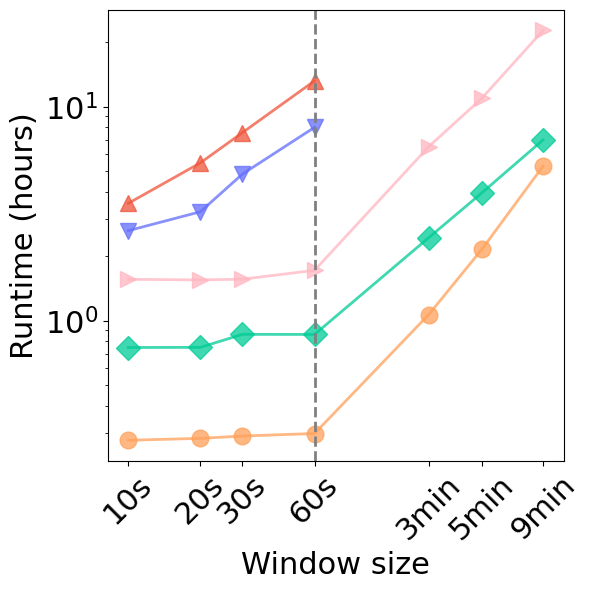

In [5]:
plt.figure(figsize=(6, 6))

# Left y-axis (runtime)
plt.plot(x_xlstm, xlstm_progression_runtime['mean'], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.plot(x_jepa, jepa_progression_runtime['mean'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'], linewidth=2)
# plt.plot(x_trans, trans_progression_runtime['mean'], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'], linewidth=2)
plt.plot(x_ecgfm, ecgfm_progression_runtime['mean'], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.plot(x_stmem, stmem_progression_runtime['mean'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'], linewidth=2)
plt.plot(x_ecgcpc, ecgcpc_progression_runtime['mean'], marker='>', markersize=12, label='ECG-CPC', linestyle='-', color=colors_idxs['best_ecgcpc_ft'], linewidth=2)


plt.xlabel("Window size", fontdict={'size': 22})
plt.ylabel("Runtime (hours)", fontdict={'size': 22})
plt.tick_params(axis='y')

#set font yticks
plt.tick_params(axis='y', labelsize=22)
#plt.yscale('log')
plt.loglog()

# add a vertical dotted line at 60
plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'],
    rotation=45,
    fontsize=22
)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)

plt.tight_layout()
plt.savefig("figs/sleep_apnea_runtime.svg", dpi=300)

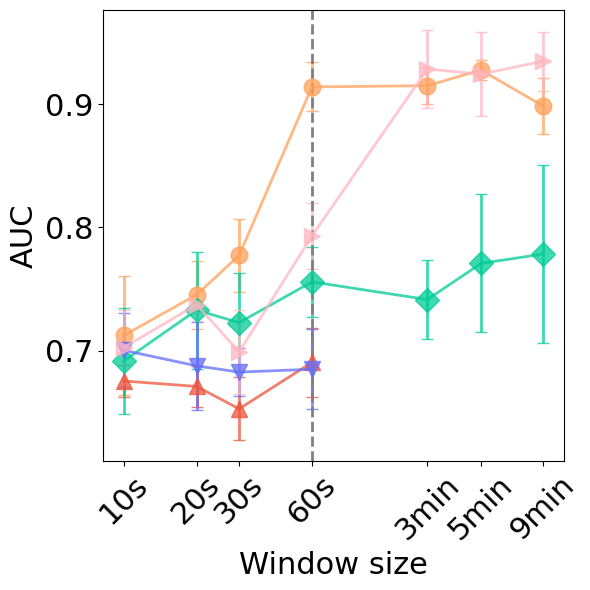

In [6]:
plt.figure(figsize=(6, 6))

# Right y-axis (AUC for xLSTM)
# ax2 = ax1.twinx()
plt.errorbar(x_xlstm, xlstm_progression_auc['mean'], yerr=xlstm_progression_auc['std'], marker='o', markersize=12, label='xECG', capsize=4, color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.errorbar(x_jepa, jepa_progression_auc['mean'], yerr=jepa_progression_auc['std'], marker='^', markersize=12, label='ECG-JEPA', capsize=4, color=colors_idxs['best_jepa_ft'], linewidth=2)
# plt.errorbar(x_trans, trans_progression_auc['mean'], yerr=trans_progression_auc['std'], marker='s', markersize=12, label='SimDINOv2\nTransf.', capsize=4, color=colors_idxs['best_trans_ft'], linewidth=2)
plt.errorbar(x_ecgfm, ecgfm_progression_auc['mean'], yerr=ecgfm_progression_auc['std'], marker='D', markersize=12, label='ECGFounder', capsize=4, color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.errorbar(x_stmem, stmem_progression_auc['mean'], yerr=stmem_progression_auc['std'], marker='v', markersize=12, label='ST-MEM', capsize=4, color=colors_idxs['best_stmem_ft'], linewidth=2)
plt.errorbar(x_ecgcpc, ecgcpc_progression_auc['mean'], yerr=ecgcpc_progression_auc['std'], marker='>', markersize=12, label='ECG-CPC', capsize=4, color=colors_idxs['best_ecgcpc_ft'], linewidth=2)


plt.ylabel("AUC", fontdict={'size': 22})
plt.tick_params(axis='y')
plt.xlabel("Window size", fontdict={'size': 22})

plt.xscale("log")
plt.tick_params(axis='y', labelsize=22)
plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'],
    rotation=45,
    fontsize=22
)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)


plt.tight_layout()
plt.savefig("figs/sleep_apnea_auc.svg", dpi=300)


In [7]:
xlstm_progression_runtime

,mean,std
group,,
best_xlstm_ft_10s,0.276146,0.006157
best_xlstm_ft_20s,0.281945,0.001063
best_xlstm_ft_30s,0.289069,0.001879
best_xlstm_ft_1m,0.296956,0.002107
best_xlstm_ft_3m,1.068406,0.004634
best_xlstm_ft_5m,2.154556,0.010523
best_xlstm_ft_9m,5.267718,0.019446


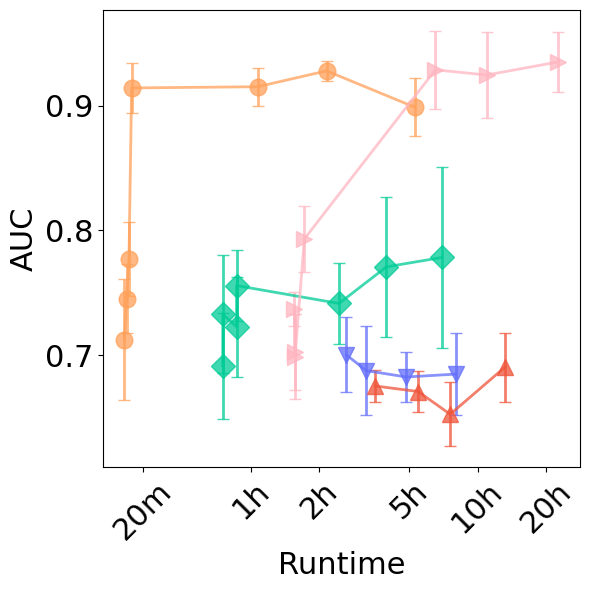

In [15]:
plt.figure(figsize=(6, 6))

# Right y-axis (AUC for xLSTM)
#  # ax2 = ax1.twinx()
# xlstm_idx =  xlstm_progression_auc['mean'].idxmax()
# plt.errorbar(xlstm_progression_runtime.loc[xlstm_idx]['mean'], xlstm_progression_auc.loc[xlstm_idx]['mean'], yerr=xlstm_progression_auc.loc[xlstm_idx]['std'], marker='o', markersize=12, label='xECG', capsize=4, color=colors_idxs['best_xlstm_ft'], linewidth=2)
# jepa_idx = jepa_progression_auc['mean'].idxmax()
# plt.errorbar(jepa_progression_runtime['mean'].loc[jepa_idx], jepa_progression_auc.loc[jepa_idx]['mean'], yerr=jepa_progression_auc.loc[jepa_idx]['std'], marker='^', markersize=12, label='ECG-JEPA', capsize=4, color=colors_idxs['best_jepa_ft'], linewidth=2)
# # plt.errorbar(x_trans, trans_progression_auc['mean'], yerr=trans_progression_auc['std'], marker='s', markersize=12, label='SimDINOv2\nTransf.', capsize=4, color=colors_idxs['best_trans_ft'], linewidth=2)

# ecgfm_idx = ecgfm_progression_auc['mean'].idxmax()
# plt.errorbar(ecgfm_progression_runtime.loc[ecgfm_idx]['mean'], ecgfm_progression_auc.loc[ecgfm_idx]['mean'], yerr=ecgfm_progression_auc.loc[ecgfm_idx]['std'], marker='D', markersize=12, label='ECGFounder', capsize=4, color=colors_idxs['best_ecgfm_ft'], linewidth=2)

# stmem_idx = stmem_progression_auc['mean'].idxmax()
# plt.errorbar(stmem_progression_runtime.loc[stmem_idx]['mean'], stmem_progression_auc.loc[stmem_idx]['mean'], yerr=stmem_progression_auc.loc[stmem_idx]['std'], marker='v', markersize=12, label='ST-MEM', capsize=4, color=colors_idxs['best_stmem_ft'], linewidth=2)

# ecgcpc_idx = ecgcpc_progression_auc['mean'].idxmax()
# plt.errorbar(ecgcpc_progression_runtime.loc[ecgcpc_idx]['mean'], ecgcpc_progression_auc.loc[ecgcpc_idx]['mean'], yerr=ecgcpc_progression_auc.loc[ecgcpc_idx]['std'], marker='>', markersize=12, label='ECG-CPC', capsize=4, color=colors_idxs['best_ecgcpc_ft'], linewidth=2)


plt.errorbar(xlstm_progression_runtime['mean'], xlstm_progression_auc['mean'], yerr=xlstm_progression_auc['std'], marker='o', markersize=12, label='xECG', capsize=4, color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.errorbar(jepa_progression_runtime['mean'], jepa_progression_auc['mean'], yerr=jepa_progression_auc['std'], marker='^', markersize=12, label='ECG-JEPA', capsize=4, color=colors_idxs['best_jepa_ft'], linewidth=2)
plt.errorbar(ecgfm_progression_runtime['mean'], ecgfm_progression_auc['mean'], yerr=ecgfm_progression_auc['std'], marker='D', markersize=12, label='ECGFounder', capsize=4, color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.errorbar(stmem_progression_runtime['mean'], stmem_progression_auc['mean'], yerr=stmem_progression_auc['std'], marker='v', markersize=12, label='ST-MEM', capsize=4, color=colors_idxs['best_stmem_ft'], linewidth=2)
plt.errorbar(ecgcpc_progression_runtime['mean'], ecgcpc_progression_auc['mean'], yerr=ecgcpc_progression_auc['std'], marker='>', markersize=12, label='ECG-CPC', capsize=4, color=colors_idxs['best_ecgcpc_ft'], linewidth=2)


plt.ylabel("AUC", fontdict={'size': 22})
plt.tick_params(axis='y')
plt.xlabel("Runtime", fontdict={'size': 22})

plt.xscale("log")
plt.tick_params(axis='y', labelsize=22)

plt.tick_params(axis='x', which='minor', bottom=False, top=False)
plt.xticks(fontsize=22)

# plt.legend(fontsize=20)

plt.xticks(
    [20 / 60 , 1, 2, 5, 10, 20],
    ['20m', '1h', '2h', '5h','10h', '20h'],
    fontsize=22,
    rotation=45,
)


plt.tight_layout()
plt.savefig("figs/sleep_apnea_auc_runtime.svg", dpi=300)

In [8]:
import pandas as pd
csv = pd.read_csv('/home/q036rl/MIT-BIH_ecg_arrhytmia/logs_lightning/train-age/best_jepa_ft/9faxr5vr/results.csv')
csv[csv['dataset'] == 'cpsc']

,id,dataset,prediction,target
817052,0,cpsc,79.90,74.0
817053,1,cpsc,39.97,49.0
817054,2,cpsc,76.56,81.0
817055,3,cpsc,74.30,45.0
817056,4,cpsc,60.12,53.0
...,...,...,...,...
823909,2867,cpsc,73.40,67.0
823910,2868,cpsc,84.20,80.0
823911,2869,cpsc,70.75,62.0
823912,2870,cpsc,78.00,78.0


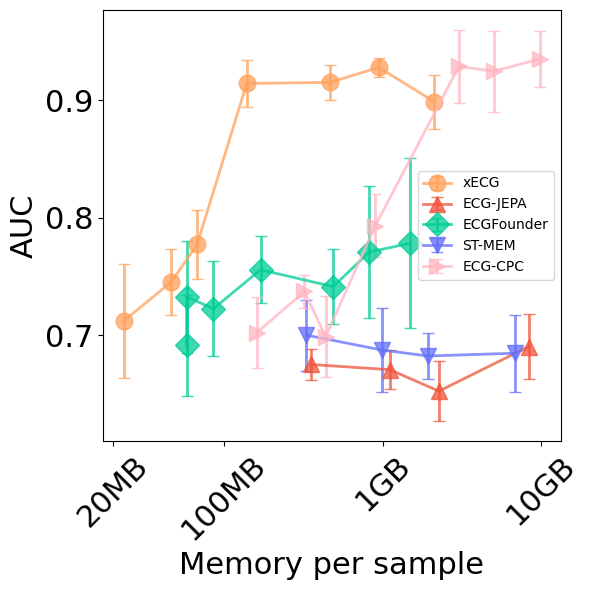

In [25]:
plt.figure(figsize=(6, 6))

# Right y-axis (AUC for xLSTM)
# ax2 = ax1.twinx()
plt.errorbar(xlstm_memory['mean'], xlstm_progression_auc['mean'], yerr=xlstm_progression_auc['std'], marker='o', markersize=12, label='xECG', capsize=4, color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.errorbar(jepa_memory['mean'], jepa_progression_auc['mean'], yerr=jepa_progression_auc['std'], marker='^', markersize=12, label='ECG-JEPA', capsize=4, color=colors_idxs['best_jepa_ft'], linewidth=2)
# plt.errorbar(x_trans, trans_progression_auc['mean'], yerr=trans_progression_auc['std'], marker='s', markersize=12, label='SimDINOv2\nTransf.', capsize=4, color=colors_idxs['best_trans_ft'], linewidth=2)
plt.errorbar(ecgfm_memory['mean'], ecgfm_progression_auc['mean'], yerr=ecgfm_progression_auc['std'], marker='D', markersize=12, label='ECGFounder', capsize=4, color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.errorbar(stmem_memory['mean'], stmem_progression_auc['mean'], yerr=stmem_progression_auc['std'], marker='v', markersize=12, label='ST-MEM', capsize=4, color=colors_idxs['best_stmem_ft'], linewidth=2)
plt.errorbar(ecgcpc_memory['mean'], ecgcpc_progression_auc['mean'], yerr=ecgcpc_progression_auc['std'], marker='>', markersize=12, label='ECG-CPC', capsize=4, color=colors_idxs['best_ecgcpc_ft'], linewidth=2)


plt.ylabel("AUC", fontdict={'size': 22})
plt.tick_params(axis='y')
plt.xlabel("Memory per sample", fontdict={'size': 22})

plt.xscale("log")
plt.tick_params(axis='y', labelsize=22)

plt.tick_params(axis='x', which='minor', bottom=False, top=False)
plt.xticks(fontsize=22)

plt.xticks(
    [0.097 / 5, 0.097, 1, 10],
    ['20MB', '100MB', '1GB', '10GB'],
    fontsize=22,
    rotation=45,
)
plt.legend()

plt.tight_layout()
plt.savefig("figs/sleep_apnea_auc_memory.svg", dpi=300)

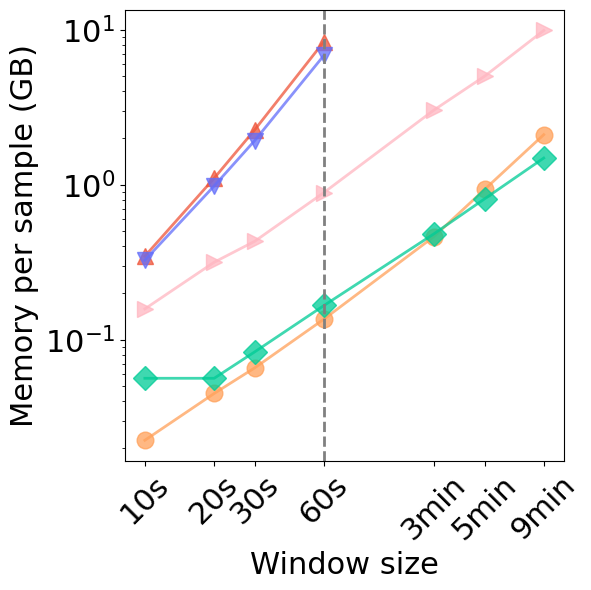

In [11]:
plt.figure(figsize=(6, 6))

# Left y-axis (runtime)
plt.plot(x_xlstm, xlstm_memory['mean'], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.plot(x_jepa, jepa_memory['mean'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'], linewidth=2)
# plt.plot(x_trans, trans_memory['mean'], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'], linewidth=2)
plt.plot(x_ecgfm, ecgfm_memory['mean'], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'], linewidth=2)
plt.plot(x_stmem, stmem_memory['mean'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'], linewidth=2)
plt.plot(x_ecgcpc, ecgcpc_memory['mean'], marker='>', markersize=12, label='ECG-CPC', linestyle='-', color=colors_idxs['best_ecgcpc_ft'], linewidth=2)

plt.xlabel("Window size", fontdict={'size': 22})
plt.ylabel("Memory per sample (GB)", fontdict={'size': 22})
plt.tick_params(axis='y')

#set font yticks
plt.loglog()
# plt.xscale("log")

# add a vertical dotted line at 60
plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'],
    rotation=45,
    fontsize=22
)
plt.yticks(fontsize=22)
# plt.yticks([0.005, 0.2, 2, 8], ['0.005', '0.2', '2', '8'], fontsize=18)

plt.tick_params(axis='x', which='minor', bottom=False, top=False, labelsize=22)
# plt.tick_params(axis='y', which='minor', bottom=False, top=False)
# plt.legend(bbox_to_anchor=(1.05, 0.8), loc='upper left', fontsize=22, frameon=False)

plt.tight_layout()
# plt.legend(fontsize=15, loc='lower right', frameon=False)

# set legend outside of the plot
plt.savefig("figs/sleep_apnea_memory.svg", dpi=300)


# computation inference

In [12]:
import bench_xecg.utils.utils as utils
from bench_xecg.config import parse_config
import bench_xecg.dataset.sleep_apnea as sleep_apnea
from bench_xecg.dataset.generic_utils import get_transforms
from torch.utils.data import DataLoader
import torch
import pandas as pd
import time
import numpy as np

from fvcore.nn import FlopCountAnalysis 

windows = [(10, 0), (20, 0), (30, 0), (60, 0), (60, 120), (60, 240), (60, 480), (60, 1440)]  # in seconds

batch_size = 1
num_workers = 1

@torch.no_grad()
def measure_inference_time(config, samples=1):
    tortn = pd.DataFrame(columns=['len', 'avg_inference_time'])
    for window_size, context_size in windows:
        try:
            config.window_size = window_size
            config.context_size = context_size

            config.max_length_signal = (config.window_size + config.context_size) * config.sampling_freq
            print(f"\n\nMeasuring inference time for window size {config.window_size}s and context size {config.context_size}s (total {config.max_length_signal} samples)")
            feature_classification = config.window_size % 60 == 0
            base_model = utils.get_base_model(config, feature_classification=feature_classification, sleep_apnea=True, model_base_path='../')
            base_model = utils.change_positional_embedding_if_needed(base_model, config)
            # print(base_model)

            base_model.eval()
            base_model.to('cuda')

            dataset =  sleep_apnea.ECGSleepApneaDataset(config, split='train', augmentations=get_transforms(config))
            dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, collate_fn=sleep_apnea.make_collate_fn(config, split='train'), drop_last=True)

            # Measure inference time
            total_time = 0.0
            total_samples = 0
            total_flops = 0
            for i, batch in enumerate(dataloader):
                if total_samples >= samples:
                    break
                x = batch["signals"].to('cuda')
                targets = batch['labels'].to('cuda')

                if i == 0:
                    print('signal shape:', x.shape)

                torch.cuda.synchronize()  # ensure GPU finished
                # Measure time    
                # with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                start_time = time.time()
                _ = base_model(x)
                torch.cuda.synchronize()  # ensure GPU finished
                # preds = (torch.sigmoid(logits) > 0.5).float()
                # loss_cls = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='mean')
                # loss_cls.backward()
                end_time = time.time()

                total_time += (end_time - start_time)
                total_samples += config.batch_size  

                flops = FlopCountAnalysis(base_model, x)
                flops.tracer_warnings('none')
                total_flops += flops.total()

            avg_time = total_time / total_samples if total_samples > 0 else 0
            avg_flops = total_flops / total_samples  if total_samples > 0 else 0

            print(f"Window: {window_size}s, Context: {context_size}s, Avg Inference Time: {avg_time:.6f}s, FLOPs: {np.log(avg_flops)}")

            # add row to dataframe
            tortn = pd.concat([tortn, pd.DataFrame({'len': [window_size + context_size], 'avg_inference_time': [avg_time], 'avg_flops': [avg_flops]})], ignore_index=True)
        except Exception as e:
            tortn = pd.concat([tortn, pd.DataFrame({'len': [window_size + context_size], 'avg_inference_time': [np.nan], 'avg_flops':[np.nan]})], ignore_index=True)
            print(e)
    return tortn
        

/home/q036rl/MIT-BIH_ecg_arrhytmia/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0612 12:24:59.902000 1600180 torch/utils/cpp_extension.py:118] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
/home/q036rl/MIT-BIH_ecg_arrhytmia/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [13]:
config_orig = parse_config('../configs/sleep_apnea/stmem_ft_10s.yaml', '../config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = False
config_orig.use_st_mem = True
config_orig.sampling_freq = 250
config_orig.patch_size = 75

stmem_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 2500 samples)
_IncompatibleKeys(missing_keys=['head.0.weight', 'head.0.bias'], unexpected_keys=[])
Changing positional embedding to new sequence length 0
Original positional embedding shape: torch.Size([1, 32, 768])
repeated left pe shape: torch.Size([1, 1, 768])
repeated right pe shape: torch.Size([1, 1, 768])
New positional embedding shape: torch.Size([1, 34, 768])
Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx


Measuring inference time for window size 20s and context size 0s (total 5000 samples)
_IncompatibleKeys(missing_keys=['head.0.weight', 'head.0.bias'], unexpected_keys=[])
Changing positional embedding to new sequence length 0
Original positional embedding shape: torch.Size([1, 32, 768])
repeated left pe shape: torch.Size([1, 18, 768])
repeated right pe shape: torch.Size([1, 18, 768])
New positional em

In [14]:
config_orig = parse_config('../configs/sleep_apnea/xlstm_ft_10s.yaml', '../config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = False
config_orig.use_st_mem = False

config_orig.sampling_freq = 100
config_orig.patch_size = 25
config_orig.xlstm_config = ["s","s","m","m","s","s","m","m","s"]
# config_orig.checkpoint = 'pretrained_models/simdino/no_mimic_xlstm.ckpt'

config_orig.embedding_size = 1024
config_orig.encoder_type = 'vanilla'
config_orig.cls_type = 'avg'

xecg_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 1000 samples)
using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
'CUDA_LIB'


Measuring inference time for window size 20s and context size 0s (total 2000 samples)
using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
'CUDA_LIB'


Measuring inference time for window size 30s and context size 0s (total 3000 samples)
using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
'CUDA_LIB'


Measuring inference time for window size 60s and context size 0s (total 6000 samples)
using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
'CUDA_LIB'


Measuring inference time for window size 60s and context size 120s (total 18000 samples)
using linear patch embedding
creating xlstm with slstm at:  [0, 1, 4, 5, 8]
'CUDA_LIB'


Measuring inference time for window size 60s and context size 240s (total 30000 samples)
using linear patch embedding
cr

In [15]:
config_orig = parse_config('../configs/sleep_apnea/ecgfm_ft_10s.yaml', '../config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = True
config_orig.use_ecg_jepa = False
config_orig.use_stmem = False

config_orig.sampling_freq = 500

ecg_fm_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 5000 samples)
Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.


Measuring inference time for window size 20s and context size 0s (total 10000 samples)
Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.


Measuring inference time for window size 30s and context size 0s (total 15000 samples)
Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.


Measuring inference time for window size 60s and context 

In [16]:
config_orig = parse_config('../configs/sleep_apnea/transformer_ft_10s.yaml', '../config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = False
config_orig.use_st_mem = False

config_orig.patch_size = 25

config_orig.encoder_type = 'transformer'
config_orig.embedding_size = 768

config_orig.sampling_freq = 100


transformer_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 1000 samples)
using linear patch embedding
[Errno 2] No such file or directory: 'pretrained_models/transformer.ckpt'


Measuring inference time for window size 20s and context size 0s (total 2000 samples)
using linear patch embedding
[Errno 2] No such file or directory: 'pretrained_models/transformer.ckpt'


Measuring inference time for window size 30s and context size 0s (total 3000 samples)
using linear patch embedding
[Errno 2] No such file or directory: 'pretrained_models/transformer.ckpt'


Measuring inference time for window size 60s and context size 0s (total 6000 samples)
using linear patch embedding
[Errno 2] No such file or directory: 'pretrained_models/transformer.ckpt'


Measuring inference time for window size 60s and context size 120s (total 18000 samples)
using linear patch embedding
[Errno 2] No such file or directory: 'pretrained_models/transformer.ckpt'


Measuring inference time for window size

In [21]:
config_orig = parse_config('../configs/sleep_apnea/ecgcpc_ft_10s.yaml', '../config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_cpc = True
config_orig.use_stmem = False
config_orig.sampling_freq = 240
config_orig.patch_size = 2

ecgcpc_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 2400 samples)
[Errno 2] No such file or directory: './pretrained_models/ecg_cpc/last_11597276_state_dict.ckpt'


Measuring inference time for window size 20s and context size 0s (total 4800 samples)
[Errno 2] No such file or directory: './pretrained_models/ecg_cpc/last_11597276_state_dict.ckpt'


Measuring inference time for window size 30s and context size 0s (total 7200 samples)
[Errno 2] No such file or directory: './pretrained_models/ecg_cpc/last_11597276_state_dict.ckpt'


Measuring inference time for window size 60s and context size 0s (total 14400 samples)
[Errno 2] No such file or directory: './pretrained_models/ecg_cpc/last_11597276_state_dict.ckpt'


Measuring inference time for window size 60s and context size 120s (total 43200 samples)
[Errno 2] No such file or directory: './pretrained_models/ecg_cpc/last_11597276_state_dict.ckpt'


Measuring inference time for window size 60s and context size 240s (t

In [ ]:
config_orig = parse_config('configs/train_sleep_apnea_run_config.yaml',  '../config_defaults/train_sleep_apnea_defaults.yaml')
config_orig.linear_probing = True
config_orig.batch_size = batch_size
config_orig.num_workers = num_workers

config_orig.use_ecg_founder = False
config_orig.use_ecg_jepa = True
config_orig.use_stmem = False
config_orig.sampling_freq = 250
config_orig.patch_size = 50
config_orig.leads = ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

jepa_times = measure_inference_time(config_orig)



Measuring inference time for window size 10s and context size 0s (total 2500 samples)
Creating JEPA with c=8, p=50, t=50
_IncompatibleKeys(missing_keys=['pos_embed'], unexpected_keys=[])
Changing positional embedding to new sequence length 0
Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW


Measuring inference time for window size 20s and context size 0s (total 5000 samples)
Creating JEPA with c=8, p=100, t=50
_IncompatibleKeys(missing_keys=['pos_embed'], unexpected_keys=[])
Changing positional embedding to new sequence length 0
Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW


Measuring inference time for window size 30s and context size 0s (total 7500 sample

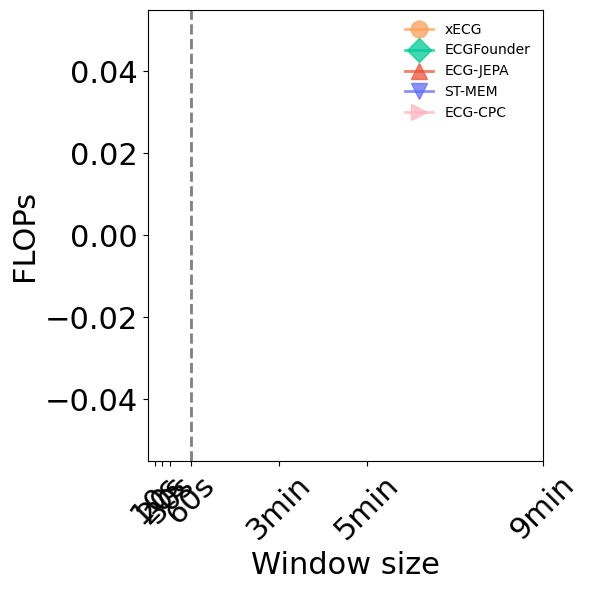

In [ ]:
import matplotlib.pyplot as plt

# plot times
plt.figure(figsize=(6, 6))

plt.plot(xecg_times['len'][:-1], xecg_times['avg_flops'][:-1], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'], linewidth=2)
plt.plot(ecg_fm_times['len'][:-1], ecg_fm_times['avg_flops'][:-1], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'],linewidth=2)
plt.plot(jepa_times['len'], jepa_times['avg_flops'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'],linewidth=2)
plt.plot(stmem_times['len'], stmem_times['avg_flops'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'],linewidth=2)
# plt.plot(transformer_times['len'][:-1], transformer_times['avg_flops'][:-1], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'],linewidth=2)  
plt.plot(ecgcpc_times['len'][:-1], ecgcpc_times['avg_flops'][:-1], marker='>', markersize=12, label='ECG-CPC', linestyle='-', color=colors_idxs['best_ecgcpc_ft'],linewidth=2)  

plt.xlabel("Window size", fontdict={'size': 22})
plt.ylabel("FLOPs", fontdict={'size': 22})
plt.tick_params(axis='y')
#set font yticks
plt.tick_params(axis='y', labelsize=22)
# plt.loglog()

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540], #, 1500],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'], #, '27min'],
    rotation=45,
    fontsize=22
)

plt.axvline(x=60, color='gray', linestyle='--', linewidth=2)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)   
plt.tight_layout()
plt.legend(frameon=False)
plt.savefig('figs/sleep_apnea_flops_nonlog.svg', dpi=300)

In [ ]:
import matplotlib.pyplot as plt

# plot times
plt.figure(figsize=(6, 6))

plt.plot(xecg_times['len'][:-1], xecg_times['avg_inference_time'][:-1], marker='o', markersize=12, label='xECG', linestyle='-', color=colors_idxs['best_xlstm_ft'])
plt.plot(ecg_fm_times['len'][:-1], ecg_fm_times['avg_inference_time'][:-1], marker='D', markersize=12, label='ECGFounder', linestyle='-', color=colors_idxs['best_ecgfm_ft'])
plt.plot(jepa_times['len'], jepa_times['avg_inference_time'], marker='^', markersize=12, label='ECG-JEPA', linestyle='-', color=colors_idxs['best_jepa_ft'])
plt.plot(stmem_times['len'], stmem_times['avg_inference_time'], marker='v', markersize=12, label='ST-MEM', linestyle='-', color=colors_idxs['best_stmem_ft'])
plt.plot(transformer_times['len'][:-1], transformer_times['avg_inference_time'][:-1], marker='s', markersize=12, label='SimDINOv2\nTransf.', linestyle='-', color=colors_idxs['best_trans_ft'])  
plt.xlabel("Window + Context size (s)", fontdict={'size': 22})
plt.ylabel("Avg Inference Time (s)", fontdict={'size': 22})
plt.tick_params(axis='y')
#set font yticks
plt.tick_params(axis='y', labelsize=22)
plt.loglog()

plt.xticks(
    [10, 20, 30, 60, 180, 300, 540], #,, 1500],
    ['10s', '20s', '30s', '60s', '3min', '5min', '9min'], # '27min'],
    rotation=45,
    fontsize=22
)
plt.tick_params(axis='x', which='minor', bottom=False, top=False)   
plt.tight_layout()
plt.savefig('/home/q036rl/MIT-BIH_ecg_arrhytmia/figs/sleep_apnea_avg_inference.svg', dpi=300)

ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7ebc110be980> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 600x600 with 1 Axes>